In [31]:
import os
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from fcd import calculate_frechet_distance, canonical_smiles, get_fcd, get_predictions, load_ref_model
from rdkit import RDLogger
from rdkit.Chem.rdmolfiles import MolFromSmiles, MolToSmiles
from rich.progress import track

In [90]:
# define order of methods
order = [
    # "GEOM Drugs Validation",
    # "GEOM Drugs Testing",
    "EQGAT-diff",
    "FlowMol",
    "GCDM",
    "GeoLDM",
    "SemlaFlow",
    "EQGAT-diff + PP",
    "FlowMol + PP",
    "GCDM + PP",
    "GeoLDM + PP",
    "SemlaFlow + PP",
    "GEOM Drugs",
    # "GEOM Drugs training data",
    "DrugBank",
    # "DrugBank Approved",
]
mapping = {
    "geom_drugs": "GEOM Drugs",
    "drugbank_approved_3d": "DrugBank",
    "eqgat_100000_predictions": "EQGAT-diff",
    "flowmol_100000_predictions": "FlowMol",
    "gcdm_100000_predictions": "GCDM",
    "geoldm_100000_predictions": "GeoLDM",
    "semlaflow_100000_predictions": "SemlaFlow",
    "eqgat_100000_predictions_pp": "EQGAT-diff",
    "flowmol_100000_predictions_pp": "FlowMol",
    "gcdm_100000_predictions_pp": "GCDM",
    "geoldm_100000_predictions_pp": "GeoLDM",
    "semlaflow_100000_predictions_pp": "SemlaFlow",
}

In [4]:
path = Path("/homes/buttensc/Network/Projects/3d_mol_gen_benchmark/data/03_evaluation")

In [9]:
activations = {p.stem.split(".")[0]: np.load(p, allow_pickle=True) for p in track(path.rglob("*.fcd.npy"))}

In [ ]:
act1 = activations["geom_drugs"]
# act1 = activations["geom_drugs_pp"]
# act1 = activations["drugbank_approved_2d_pp"]
act1 = activations["drugbank_approved_3d"]
# act1 = activations["drugbank_approved_3d_pp"]
act2 = activations["eqgat_100000_predictions"]

mu1 = np.mean(act1, axis=0)
sigma1 = np.cov(act1.T)
mu2 = np.mean(act2, axis=0)
sigma2 = np.cov(act2.T)
fcd_score = calculate_frechet_distance(mu1=mu1, mu2=mu2, sigma1=sigma1, sigma2=sigma2)
print("FCD: ", fcd_score)

FCD:  8.923611998341102


In [91]:
sets = [
    "geom_drugs",
    "drugbank_approved_3d",
    "eqgat_100000_predictions_pp",
    "flowmol_100000_predictions_pp",
    "gcdm_100000_predictions_pp",
    "geoldm_100000_predictions_pp",
    "semlaflow_100000_predictions_pp",
]
sets

['geom_drugs',
 'drugbank_approved_3d',
 'eqgat_100000_predictions_pp',
 'flowmol_100000_predictions_pp',
 'gcdm_100000_predictions_pp',
 'geoldm_100000_predictions_pp',
 'semlaflow_100000_predictions_pp']

In [92]:
fcds = []
for set1 in sets:
    for set2 in sets:
        act1 = activations[set1]
        act2 = activations[set2]
        mu1 = np.mean(act1, axis=0)
        sigma1 = np.cov(act1.T)
        mu2 = np.mean(act2, axis=0)
        sigma2 = np.cov(act2.T)
        fcd_score = calculate_frechet_distance(mu1=mu1, mu2=mu2, sigma1=sigma1, sigma2=sigma2)
        fcds.append((set1, set2, fcd_score))

df = pd.DataFrame(fcds, columns=["set1", "set2", "fcd"])
df["set1"] = pd.Categorical(df["set1"].map(mapping), categories=order, ordered=True)
df["set2"] = pd.Categorical(df["set2"].map(mapping), categories=order, ordered=True)
df["fcd"] = df["fcd"].astype(float).clip(lower=0.0)

In [93]:
df_pivot = df.pivot(index="set1", columns="set2", values="fcd")
df_pivot.index.name = None
df_pivot.columns.name = None

<Axes: >

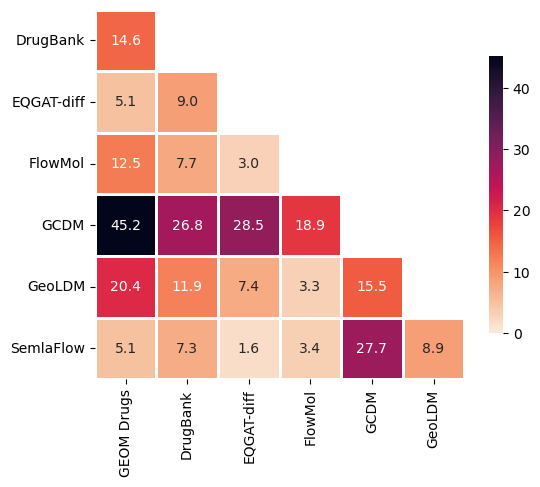

In [111]:
mask = np.triu(np.ones_like(df_pivot.to_numpy(), dtype=bool))
# cmap = sns.diverging_palette(100, 0, as_cmap=True)
# cmap = sns.light_palette("seagreen", as_cmap=True)
cmap = sns.color_palette("rocket_r", as_cmap=True)
sns.heatmap(
    df_pivot.iloc[1:, :-1],
    mask=mask[1:, :-1],
    cmap=cmap,
    square=True,
    linewidths=0.75,
    cbar_kws={"shrink": 0.75},
    vmin=0,
    annot=True,
    fmt=".1f",
)

In [113]:
for set in sets:
    print(set, len(activations[set]))

geom_drugs 301855
drugbank_approved_3d 2066
eqgat_100000_predictions_pp 87068
flowmol_100000_predictions_pp 87231
gcdm_100000_predictions_pp 95486
geoldm_100000_predictions_pp 73787
semlaflow_100000_predictions_pp 94874
